In [4]:
import pickle as pkl
import pandas as pd
from load_performances import Performance_Loader
from ir_metric_tool import IR_Metrics
import numpy as np
from matrix_calculation_tools import *
from correlation_tool import *

material_path = '../../rag_utility'

In [5]:
from sentence_splitter import SentenceSplitter
splitter = SentenceSplitter(language='en')

In [7]:
f = open(f'{material_path}/doc_dicts/msmarco_passage_dict.pkl', 'rb')
doc_dict = pkl.load(f)
f.close()

In [15]:
material_path = '../../rag_utility'
_ret = 'bm25'
_k = 3

dl_19_res = pd.read_csv(f'{material_path}/res/{_ret}_dl_19.csv')
dl_20_res = pd.read_csv(f'{material_path}/res/{_ret}_dl_20.csv')
dl_res = pd.concat([dl_19_res, dl_20_res])
dl_res.qid = dl_res.qid.astype('str')

doc_length_dict = {}
for qid in dl_res.qid.unique():

    length_list = []
    doc_texts = dl_res[(dl_res.qid == qid)&(dl_res['rank']<50)].docno.apply(lambda x: doc_dict[str(x)]).values
    sentences = []
    for doc_text in doc_texts:
        length_list.append(len(splitter.split(doc_text)))
    doc_length_dict.update({qid: length_list})

In [16]:
dl_ir_metrics = IR_Metrics()

ir_metric_dicts = dl_ir_metrics.get_ir_metric_dict(dl_res, 0, _k)

100%|██████████| 97/97 [00:02<00:00, 47.58it/s]


In [17]:
from qpp_methods import *

qpp = QPP()
qpp_evals = {}

21:13:49.205 [main] WARN org.terrier.structures.BaseCompressingMetaIndex -- Structure meta reading data file directly from disk (SLOW) - try index.meta.data-source=fileinmem in the index properties file. 1.9 GiB of memory would be required.


In [18]:
import pyterrier_dr

tct_model = pyterrier_dr.TctColBert()
tct_index = pyterrier_dr.FlexIndex('/nfs/indices/msmarco-passage.tct-hnp.flex')

# tct_index.vec_loader()

In [19]:
pfm_loader = Performance_Loader()

# kshot_pfms = pfm_loader.load_itg_performances(_ret, _k)
kshot_pfms = pfm_loader.load_sep_performances(_ret, _k)
zeroshot_pfms = pfm_loader.load_0shot_performances()

utility_dict = {}
for qid in set(kshot_pfms.keys()).intersection(set(zeroshot_pfms.keys())):
    # utility_dict.update({qid: (kshot_pfms[qid] - zeroshot_pfms[qid])/zeroshot_pfms[qid]})
    utility_dict.update({qid: (kshot_pfms[qid] - zeroshot_pfms[qid])})

#### Load perplexity

In [20]:
import json

f = open(f'../coherence_eval/log_prob_temp_res/full_context/dl_{_ret}_{_k}.json')
k_probs = json.load(f)
f.close()

In [22]:
from scipy import stats

print('with answer quality')

correlated_lists = [[], []]

for qid in kshot_pfms:
    correlated_lists[0].append(k_probs[qid])
    correlated_lists[1].append(kshot_pfms[qid])

print('r', stats.pearsonr(correlated_lists[0], correlated_lists[1]))
print('rho', stats.spearmanr(correlated_lists[0], correlated_lists[1]))
print('tau', stats.kendalltau(correlated_lists[0], correlated_lists[1]))

print('with answer quality')
print(round(stats.pearsonr(correlated_lists[0], correlated_lists[1])[0], 4),\
     round(stats.spearmanr(correlated_lists[0], correlated_lists[1])[0], 4),\
     round(stats.kendalltau(correlated_lists[0], correlated_lists[1])[0], 4))

with answer quality
r PearsonRResult(statistic=0.2706944956652693, pvalue=0.007324180495871498)
rho SignificanceResult(statistic=0.24201979026789586, pvalue=0.01692470341787819)
tau SignificanceResult(statistic=0.16799141096545445, pvalue=0.014799645063244615)
with answer quality
0.2707 0.242 0.168


In [23]:
from scipy import stats

print('with utility')

correlated_lists = [[], []]

for qid in kshot_pfms:
    correlated_lists[0].append(k_probs[qid])
    correlated_lists[1].append(utility_dict[qid])

print('r', stats.pearsonr(correlated_lists[0], correlated_lists[1]))
print('rho', stats.spearmanr(correlated_lists[0], correlated_lists[1]))
print('tau', stats.kendalltau(correlated_lists[0], correlated_lists[1]))

print('with utility')
print(round(stats.pearsonr(correlated_lists[0], correlated_lists[1])[0], 4), '\t',\
     round(stats.spearmanr(correlated_lists[0], correlated_lists[1])[0], 4), '\t',\
     round(stats.kendalltau(correlated_lists[0], correlated_lists[1])[0], 4))

with utility
r PearsonRResult(statistic=0.1618533601443285, pvalue=0.11322375007765581)
rho SignificanceResult(statistic=0.1723067819492189, pvalue=0.09147400952563266)
tau SignificanceResult(statistic=0.10827067919001157, pvalue=0.11622735304722051)
with utility
0.1619 	 0.1723 	 0.1083


## Calculate QPP

In [725]:
# qid = dl_res.qid.unique()[0]
# print(qid)
# import timeit

# s = timeit.default_timer()
# for qid in dl_res.qid.unique():
#     qpp.spatial_prediction(dl_res, qid, _k, tct_model, tct_index)
# e = timeit.default_timer()

# print(e-s)

In [726]:
import timeit
s = timeit.default_timer()
df_dense_qpp = qpp.qpp_in_batch(dl_res, 'spatial', _k, tct_model, tct_index)
e = timeit.default_timer()

print(e-s)
df_dense_qpp

2.8193820021115243


,qid,qpp_estimate,parameters,qpp_method
0,1030303,1302.886475,{'k': 5},spatial
1,1037496,1450.112427,{'k': 5},spatial
2,1037798,1375.465942,{'k': 5},spatial
3,1043135,1455.546875,{'k': 5},spatial
4,104861,1684.059937,{'k': 5},spatial
...,...,...,...,...
92,915593,1497.572021,{'k': 5},spatial
93,938400,1510.410156,{'k': 5},spatial
94,940547,1521.352051,{'k': 5},spatial
95,962179,1375.784424,{'k': 5},spatial


In [727]:
import timeit
s = timeit.default_timer()
df_a_ratio_qpp = qpp.qpp_in_batch(dl_res, 'a_ratio', _k, tct_model, tct_index)
e = timeit.default_timer()

print(e-s)
df_a_ratio_qpp

0.17732869600877166


,qid,qpp_estimate,parameters,qpp_method
0,1030303,6.052067,"{'k': 50, 'ratio': 0.1}",a_ratio
1,1037496,3.065091,"{'k': 50, 'ratio': 0.1}",a_ratio
2,1037798,19.090063,"{'k': 50, 'ratio': 0.1}",a_ratio
3,1043135,1.207188,"{'k': 50, 'ratio': 0.1}",a_ratio
4,104861,4.338361,"{'k': 50, 'ratio': 0.1}",a_ratio
...,...,...,...,...
92,915593,1.859548,"{'k': 50, 'ratio': 0.1}",a_ratio
93,938400,2.506994,"{'k': 50, 'ratio': 0.1}",a_ratio
94,940547,1.900530,"{'k': 50, 'ratio': 0.1}",a_ratio
95,962179,19.577372,"{'k': 50, 'ratio': 0.1}",a_ratio


In [728]:
import timeit
s = timeit.default_timer()
df_nqc_qpp = qpp.qpp_in_batch(dl_res, 'nqc', _k, tct_model, tct_index)
e = timeit.default_timer()

print(e-s)
df_nqc_qpp

0.1360213621519506


,qid,qpp_estimate,parameters,qpp_method
0,1030303,0.000549,{'k': 5},nqc
1,1037496,0.000056,{'k': 5},nqc
2,1037798,0.000297,{'k': 5},nqc
3,1043135,0.000098,{'k': 5},nqc
4,104861,0.000961,{'k': 5},nqc
...,...,...,...,...
92,915593,0.006800,{'k': 5},nqc
93,938400,0.000184,{'k': 5},nqc
94,940547,0.001155,{'k': 5},nqc
95,962179,0.003156,{'k': 5},nqc


In [729]:
qpp_df = pd.concat([df_a_ratio_qpp, df_dense_qpp])
qpp_df = pd.concat([qpp_df, df_nqc_qpp])
qpp_df[qpp_df.qpp_method=='spatial']

,qid,qpp_estimate,parameters,qpp_method
0,1030303,1302.886475,{'k': 5},spatial
1,1037496,1450.112427,{'k': 5},spatial
2,1037798,1375.465942,{'k': 5},spatial
3,1043135,1455.546875,{'k': 5},spatial
4,104861,1684.059937,{'k': 5},spatial
...,...,...,...,...
92,915593,1497.572021,{'k': 5},spatial
93,938400,1510.410156,{'k': 5},spatial
94,940547,1521.352051,{'k': 5},spatial
95,962179,1375.784424,{'k': 5},spatial


In [730]:
count = 0

for i in dl_res.groupby(['qid']):
    if(count>=1):
        break
    count+=1
    qid = i[0][0]
    qid_df = i[1]
    qid_df = qid_df[qid_df['rank']<_k]
    query_emb = tct_model(qid_df[['qid', 'query']].iloc[:1])['query_vec'].values[0]

    emb_cluster = np.expand_dims(query_emb, axis=0)
    doc_embs = tct_index.vec_loader()(pd.DataFrame(qid_df))['doc_vec'].values
    for e in doc_embs:
        emb_cluster = np.append(emb_cluster, np.expand_dims(e, axis=0), axis=0)

    max_emb = np.max(emb_cluster, axis=0)
    min_emb = np.min(emb_cluster, axis=0)
    edge_emb = max_emb - min_emb
    prediction = -np.sum(np.log(edge_emb))

    print(prediction.item())

1302.886474609375


In [731]:
def spatial_qpp(group):
    group = group[group['rank']<_k]
    query_emb = tct_model(group[['qid', 'query']].iloc[:1])['query_vec'].values[0]

    emb_cluster = np.expand_dims(query_emb, axis=0)
    doc_embs = tct_index.vec_loader()(pd.DataFrame(qid_df))['doc_vec'].values
    for e in doc_embs:
        emb_cluster = np.append(emb_cluster, np.expand_dims(e, axis=0), axis=0)

    max_emb = np.max(emb_cluster, axis=0)
    min_emb = np.min(emb_cluster, axis=0)
    edge_emb = max_emb - min_emb
    prediction = -np.sum(np.log(edge_emb))

    return prediction.item()

In [732]:
import timeit

s = timeit.default_timer()
dense_qpp_df = dl_res.groupby(['qid']).apply(spatial_qpp).reset_index(name='dense_qpp')
e = timeit.default_timer()

print(e-s)

dense_qpp_df['qpp_method'] = 'dense_qpp'
dense_qpp_df['parameters']= str({'k': _k})

2.7635660050436854


### Coherence Tests

In [733]:
# load coherence matrix
f = open(f'../coherence_res/dl_20_{_ret}.pkl', 'rb') # currently we calculates the sentence-pair coherence to 20
matrix = pkl.load(f)
f.close()

In [734]:
def cal_coherence(_window=0, _step=1): # 0 for document average, no overlaping
    _coh_dict = {}
    
    for _qid, mtx in matrix.items():
        qid = str(_qid)
        stc_num_in_top_k = np.sum(doc_length_dict[qid][:_k])
        cut_mtx = np.matrix(mtx)[:stc_num_in_top_k][:stc_num_in_top_k]
    
        _sub_cohs = [] # coherence in a sub-piece of context

        if(_window == 0):
            ## document average
            # print(doc_length_dict[qid])
            _start = 0
            for _d_start in doc_length_dict[qid][:_k]:
                if(_d_start > 1):
                    submat = cut_mtx[_start:_start+_d_start,_start:_start+_d_start]
                    _sub_cohs.append(cal_column_avg_upper_triangle(submat))
                _start += _d_start

        else:
            ## fixed length average            
            _real_window = min(stc_num_in_top_k, _window)
            if(_real_window == 1):
                continue
            for _start in range(0, stc_num_in_top_k-_real_window+1, _step):
                submat = cut_mtx[_start:_start+_real_window,_start:_start+_real_window]
                _sub_cohs.append(cal_column_avg_upper_triangle(submat))
        
        if(len(_sub_cohs) > 0):
            # _coh_dict.update({str(qid): _sub_cohs[-1]})
            # weight_list = []
            # for i in range(len(_sub_cohs)):
            #     weight_list.append(math.exp(-(2*i/len(_sub_cohs)-1)**2))
                # weight_list.append((i+1)/(len(_sub_cohs)+1))
                
            # print(qid, _sub_cohs)
            # weighted_avg = np.dot(weight_list, _sub_cohs)/sum(weight_list)
            # _coh_dict.update({str(qid): weighted_avg})
            # print(weighted_avg)
            _coh_dict.update({str(qid): np.mean(_sub_cohs)})
            # _coh_dict.update({str(qid): _sub_cohs[0]})
            # print(qid, doc_length_dict[qid][:_k], np.mean(_sub_cohs))
    return _coh_dict

with dense qpp
should be estimated:  97 ; number of estimations:  97 ; really estimated:  97
r: 0.11163530062297478
tau: 0.02061855670103093


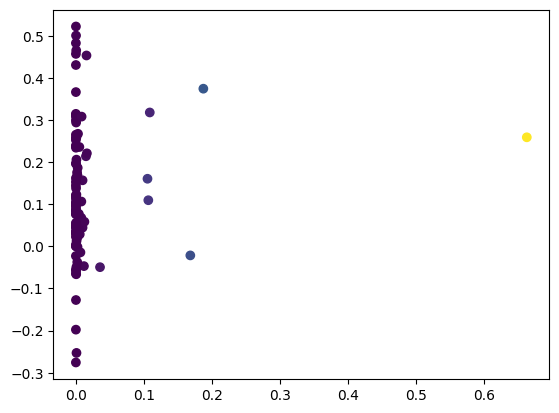

only dense qpp
should be estimated:  97 ; number of estimations:  97 ; really estimated:  97
r: 0.10452577327969004
tau: 0.0034364261168384883


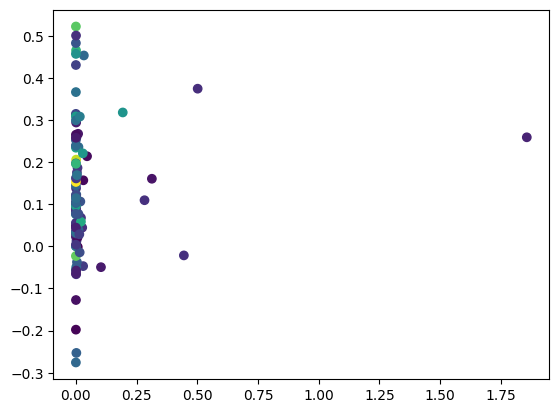

only coh
should be estimated:  97 ; number of estimations:  97 ; really estimated:  97
r: 0.2446796662458594
tau: 0.1589347079037801


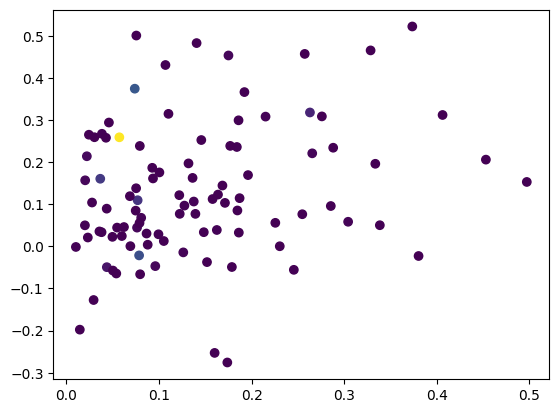

{'r': PearsonRResult(statistic=0.2446796662458594, pvalue=0.01571745874391577),
 'tau': SignificanceResult(statistic=0.1589347079037801, pvalue=0.021092644173514117),
 'rho': SignificanceResult(statistic=0.2355223017041868, pvalue=0.020215405688012333)}

In [735]:
import math
_w = 5
_s = math.ceil(_w/2) # it is the convention

coh_dict = cal_coherence(_window=_w, _step=_s)
min_coh, max_coh = min(coh_dict.values()), max(coh_dict.values())
# coh_dict = dict({i[0]: (i[1]-min_coh)/(max_coh-min_coh) for i in coh_dict.items()})

qpp_df_select = qpp_df[qpp_df.qpp_method=='nqc']

qpp_dict = dict(zip(qpp_df_select.qid.values, qpp_df_select.qpp_estimate.values))
relevance_dict = ir_metric_dicts['ndcg']

min_qpp, max_qpp = qpp_df_select.qpp_estimate.min(), qpp_df_select.qpp_estimate.max()
# qpp_dict = dict(zip(qpp_df_select.qid.values, qpp_df_select.qpp_estimate.apply(lambda x: (x-min_qpp)/(max_qpp-min_qpp)).values))
# qpp_dict = dict(zip(qpp_df_select.qid.values, qpp_df_select.qpp_estimate.apply(lambda x: (x-1200)).values))

# union_dict = {}
# print('with ndcg')
# for qid in set(relevance_dict.keys()).intersection(set(coh_dict.keys())):
#     union_dict.update({qid: relevance_dict[qid]*coh_dict[qid]})
# correlator(utility_dict, union_dict, relevance_dict)

union_dict = {}
print('with dense qpp')
for qid in set(qpp_dict.keys()).intersection(set(coh_dict.keys())):
    # union_dict.update({qid: math.log(qpp_dict[qid]) + math.log(coh_dict[qid])})
    # union_dict.update({qid: qpp_dict[qid]*math.pow(coh_dict[qid], qpp_dict[qid]/3000)})
    # union_dict.update({qid: (qpp_dict[qid]-_k*300)*(coh_dict[qid]+0.5)})
    union_dict.update({qid: qpp_dict[qid]*(0.3+coh_dict[qid])})
    # union_dict.update({qid: qpp_dict[qid] * coh_dict[qid]})
    # union_dict.update({qid: math.log(qpp_dict[qid]+1)+math.log(coh_dict[qid]+1)})
    # union_dict.update({qid: coh_dict[qid]*math.log(qpp_dict[qid])})
correlator(utility_dict, union_dict, qpp_dict)

# print('only ndcg')
# correlator(utility_dict, relevance_dict, coh_dict)

print('only dense qpp')
correlator(utility_dict, qpp_dict, coh_dict)

print('only coh')
correlator(utility_dict, coh_dict, qpp_dict)


In [736]:
import math
_w = 5
_s = math.ceil(_w/2) # it is the convention

coh_dict = cal_coherence(_window=_w, _step=_s)

qpp_df_select = qpp_df[qpp_df.qpp_method=='spatial']

qpp_dict = dict(zip(qpp_df_select.qid.values, qpp_df_select.qpp_estimate.values))
relevance_dict = ir_metric_dicts['ndcg']

for alpha in np.arange(0, 5, 0.1):

    union_dict = {}
    for qid in set(qpp_dict.keys()).intersection(set(coh_dict.keys())):
        union_dict.update({qid: alpha*math.log(qpp_dict[qid]) + math.log(coh_dict[qid])})
    
    correlated_lists = [[], []]
    print('should be estimated: ', len(utility_dict), '; number of estimations: ', len(union_dict), '; really estimated: ', len(set(utility_dict.keys()).intersection(set(union_dict.keys()))))
    for qid in set(utility_dict.keys()).intersection(set(union_dict.keys())):
        correlated_lists[0].append(utility_dict[qid])
        correlated_lists[1].append(union_dict[qid])

    print(alpha)
    print('r:', stats.pearsonr(correlated_lists[0], correlated_lists[1])[0])
    print('tau:', stats.kendalltau(correlated_lists[0], correlated_lists[1])[0])

should be estimated:  97 ; number of estimations:  97 ; really estimated:  97
0.0
r: 0.23720393649560984
tau: 0.1589347079037801
should be estimated:  97 ; number of estimations:  97 ; really estimated:  97
0.1
r: 0.23879835449928977
tau: 0.15936426116838492
should be estimated:  97 ; number of estimations:  97 ; really estimated:  97
0.2
r: 0.24035701092315925
tau: 0.16194158075601378
should be estimated:  97 ; number of estimations:  97 ; really estimated:  97
0.30000000000000004
r: 0.24188026155638553
tau: 0.16494845360824745
should be estimated:  97 ; number of estimations:  97 ; really estimated:  97
0.4
r: 0.24336848222817814
tau: 0.1670962199312715
should be estimated:  97 ; number of estimations:  97 ; really estimated:  97
0.5
r: 0.24482206735118722
tau: 0.16752577319587633
should be estimated:  97 ; number of estimations:  97 ; really estimated:  97
0.6000000000000001
r: 0.24624142849071634
tau: 0.1701030927835052
should be estimated:  97 ; number of estimations:  97 ; really

### identify the queries with high ndcg but low utility